In [1]:
import os, sys
import numpy as np
from lib import NanonisAPI, MLAAPI
from lib import Conversions, NanonisHardware, FileFunctions, DataProcessing
import time
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

file_functions = FileFunctions()
(hw_config, error) = file_functions.load_yaml("./sys/config.yml")

nanonis = NanonisAPI(hw_config = hw_config)
mla = MLAAPI(hw_config = hw_config)
#nhw = nanonis.nanonis_hardware
#data = DataProcessing()
#nanonis.link()

In [3]:
nanonis.unlink()

'Nanonis status: idle'

In [2]:
mla.link()

Check connection to MLA at 192.168.236.50
Connection ok.
Setting up MLA...
[]
[]
[]
['killall: server: no process killed\n']
192.168.236.50: Uploading files...
Uploading file: C:\IMP\imp_mla-4.6-any\mlaapi\firmware\server
   Destination   :/tmp/server
Done, uploaded 52044 bytes.
[]
[]
chmod +x /tmp/server
[]
[]
Uploading file: C:\Users\LTAFM\AppData\Local\Temp\FPGA_210_32_32_201712.top.bit.bin
   Destination   :/tmp/FPGA_210_32_32_201712.top.bit.bin
Done, uploaded 4045564 bytes.
[]
[]
['net.core.rmem_max = 16777216\n']
[]
/tmp/server > /dev/null 2>&1 &
['1\n']
[]
Reading: /mnt/mmc/settings/hconfig.ini
Done setting up MLA.
Connecting to MLA server...
S: Connected..
Configuring hardware.

S: Reloading FPGA with: /tmp/FPGA_210_32_32_201712.top.bit.bin

S: Reloading FPGA with: /tmp/FPGA_210_32_32_201712.top.bit.bin

Starting lockin.
Starting ARB.
Starting OSC.
Starting feedback.
Loading calibration: factory.ini
Startup sequence finished.
----------------------------------------------------

In [8]:
mla.unlink()

192.168.236.50: ok quit


In [14]:
mla.set_base_frequency(220)

In [6]:
amplitudes = np.zeros(shape = mla.lockin.nr_output_freq, dtype = int) # List of 32 zeros
amplitudes[0] = .5
mla.lockin.set_amplitudes(amplitudes)

In [7]:
mla.lockin.get_amplitudes()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [27]:
(pixels, uint8_array) = mla.lockin.get_pixels(2)

np.average(pixels, axis = 1)

array([-1.36125983e-04+8.01878176e-05j, -1.36125983e-04+8.01878176e-05j,
       -4.30909870e-05+7.08964866e-05j, -1.78260957e-04-8.33585090e-05j,
        6.94804830e-05+6.07279144e-05j, -2.33567642e-05+7.47952859e-05j,
       -4.32423881e-05+5.35024248e-05j, -2.84616653e-06+7.18515865e-05j,
       -2.36954477e-05+8.22601205e-05j,  2.54542268e-05+3.05314681e-06j,
       -2.26950813e-05+2.14563988e-06j,  3.15111517e-05+4.27098935e-05j,
        1.28594716e-05-3.51343187e-05j, -3.00860779e-05-6.12782422e-06j,
        6.68115245e-05-1.24339146e-05j,  2.51961004e-05-3.82519813e-05j,
        4.03634964e-05+1.18884348e-05j, -1.82402537e-05+8.86429493e-05j,
       -3.91917789e-06-2.57692487e-05j,  3.02946556e-05+2.33449250e-05j,
        1.26763710e-05+3.34080610e-05j, -1.30914868e-05+3.81087005e-05j,
       -2.86215223e-06+7.76258668e-05j, -8.11368383e-06-3.40739461e-05j,
        1.60351189e-05+8.20906338e-06j, -2.17623774e-05+2.64245408e-05j,
       -1.82699066e-05+2.81737646e-05j, -2.72914388

In [ ]:
mla.unlink()

In [51]:
mla_loader.mla.disconnect()

192.168.236.50: ok quit


In [15]:
(bias, error) = nanonis.bias_update()
V_feedback = bias.get("V_nanonis (V)")
V_feedback

In [6]:
(scan_image, error) = nanonis.scan_update(channel = 14, backward = False, verbose = False)
nan_mask = np.isnan(scan_image)
scan_finished = not bool(np.any(nan_mask))
scan_finished

True

In [30]:
nanonis.unlink()

'Nanonis status: idle'

In [29]:
[x, y] = 2 * np.random.random(2) - 1
print(x)
print(y)

-0.9957694628573761
-0.5000924538264178


In [16]:
(scan_image, _) = nanonis.scan_update(14, False)

In [18]:
(grid, _) = nanonis.grid_update()

In [19]:
nanonis.find_scan_image_minmax(scan_image, grid)

{'minimum': {'pixel': np.int64(0),
  'line': np.int64(4),
  'value': np.float64(-3.227213087089421e-09),
  'x (nm)': np.float64(215.40064316645623),
  'y (nm)': np.float64(384.75051881952083)},
 'maximum': {'pixel': np.int64(63),
  'line': np.int64(46),
  'value': np.float64(-2.3051215340471106e-09),
  'x (nm)': np.float64(215.40064316645623),
  'y (nm)': np.float64(384.75051881952083)}}

In [17]:
scan_image.shape

(64, 64)

(64, 64)
214.97311798989745, 383.57590305067714


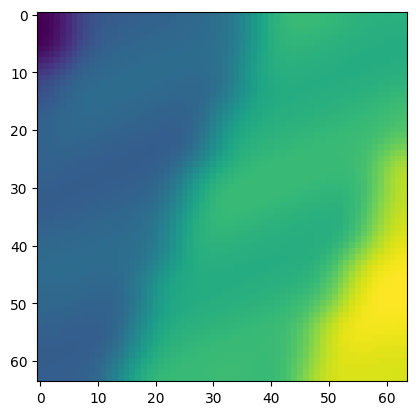

In [ ]:
print(scan_image.shape)

blurred_image = gaussian_filter(scan_image, 3)
max_line, max_pixel = np.unravel_index(blurred_image.argmax(), blurred_image.shape)
max_value = blurred_image[max_line, max_pixel]
[x_max_nm, y_max_nm] = nanonis.coords_of_grid_pixel(grid_dict = grid, indices = [max_pixel, max_line])

print(f"{x_max_nm}, {y_max_nm}")

plt.imshow(blurred_image)
plt.show()

In [35]:
nhw.get_scan_data(14)

{'scan_data': array([[-3.20950666e-09, -3.18933902e-09, -3.15648996e-09, ...,
         -2.64639732e-09, -2.59891575e-09, -3.28204375e-09],
        [-3.17126081e-09, -3.29704175e-09, -3.15774118e-09, ...,
         -2.62254884e-09, -2.57294452e-09, -3.13118176e-09],
        [-3.19937454e-09, -3.28723782e-09, -3.27164784e-09, ...,
         -2.62241584e-09, -2.59622301e-09, -3.19641535e-09],
        ...,
        [-3.01288350e-09, -3.05251668e-09, -2.89376589e-09, ...,
         -2.50822474e-09, -2.33467801e-09, -3.05251313e-09],
        [-2.91237190e-09, -2.93517499e-09, -2.92747759e-09, ...,
         -2.39247044e-09, -2.37136732e-09, -2.95819191e-09],
        [-3.00179726e-09, -2.89038327e-09, -2.93273827e-09, ...,
         -2.28297314e-09, -2.44911758e-09,  1.40129846e-45]],
       shape=(64, 64)),
 'channel_name': 'Z (m)',
 'scan_direction': 'down'}

In [11]:
nanonis.unlink()

'Nanonis status: idle'

In [5]:
nhw.get_scan_buffer()
nhw.set_scan_buffer(channel_indices = [0, 1, 2, 3, 4])

In [16]:
(scan_metadata, error) = nanonis.scan_metadata_update()
signal_dict = scan_metadata["signal_dict"]

feedback_channel_indices = [signal_dict.get(channel_name) for channel_name in ["Z (m)"]]
feedback_channel_indices = [index for index in feedback_channel_indices if index is not None]
constant_height_channel_indices = [signal_dict.get(channel_name) for channel_name in ["Lockin Demod 1 X (A)", "Lockin Demod 1 Y (A)", "Current (A)"]]
constant_height_channel_indices = [index for index in constant_height_channel_indices if index is not None]

constant_height_channel_indices
print("Switching to constant heigh mode")
nhw.set_scan_buffer(channel_indices = constant_height_channel_indices)
time.sleep(2)
print("Switching to constant heigh mode")
nhw.set_scan_buffer(channel_indices = feedback_channel_indices)

Switching to constant heigh mode
Switching to constant heigh mode


In [16]:
nanonis.get_parameter_values(["LI Demod 1 X (A)", "LI Demod 1 Y (A)", "LI Demod 2 X (A)", "LI Demod 2 Y (A)"], unlink = False)

({'LI Demod 1 X (A)': 'not found',
  'LI Demod 1 Y (A)': 'not found',
  'LI Demod 2 X (A)': 'not found',
  'LI Demod 2 Y (A)': 'not found'},
 False)

In [26]:
nanonis.unlink()

'Nanonis status: idle'

In [6]:
nhw.version = 15000

In [5]:
(scan_metadata, error) = nanonis.scan_metadata_update()
scan_channels = scan_metadata["channel_dict"]

In [13]:
list(scan_channels.values())[0]

0

In [14]:
nanonis.unlink()

'Nanonis status: idle'

In [4]:
nhw.get_signals_in_slots()

{'names': ['Current (A)',
  'Interferometer (m)',
  'Input 3 (V)',
  'Input 4 (V)',
  'Input 5 (V)',
  'Input 6 (V)',
  'Input 7 (V)',
  'Input 8 (V)',
  'Bias (V)',
  'Output 2 (V)',
  'Output 3 (V)',
  'Output 4 (V)',
  'X (m)',
  'Y (m)',
  'Z (m)',
  'W (m)',
  'OC D1 Phase (deg)',
  'OC D1 Amplitude (m)',
  'OC M1 Freq. Shift (Hz)',
  'OC M1 Excitation (V)',
  'OC D1 X (m)',
  'OC D1 Y (m)',
  'OC D2 Phase (deg)',
  'OC D2 Amplitude (m)'],
 'indices': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81]}

In [7]:
nanonis.lockin_update({"modulator_1": {"on": False}})

({'dict_name': 'lockin',
  'modulator_1': {'on': False,
   'frequency (Hz)': 600.0,
   'amplitude (mV)': 500.0,
   'phase (deg)': 0.0},
  'modulator_2': {'on': False,
   'frequency (Hz)': 1000.0,
   'amplitude (mV)': 1000.0,
   'phase (deg)': 0.0}},
 False)

In [11]:
"V_nanonis (V)".split()[0]

'V_nanonis'

In [8]:
nanonis.unlink()

'Nanonis status: idle'

In [2]:
grid_data, _ = nanonis.grid_update(unlink = True)
[x_grid, y_grid] = [grid_data.get(attribute) for attribute in ["x_grid", "y_grid"]]

In [3]:
xy_lists, _ = nanonis.grids_to_lists(grid_data, direction = "up")
xy_list_hex = xy_lists.get("xy_list")

In [8]:
#nhw.link()
for iter in range(len(xy_list_hex)):
    nhw.set_xy(xy_list_hex[iter])

In [18]:
nhw.set_xy_nm([0, 0])

In [3]:
nanonis.unlink()

'Nanonis status: idle'

In [3]:
nhw.set_lockin(1, False)

b'\x00\x00\x00\x00\x00\x00\x00\x00'

In [5]:
nhw.connect()
nhw.get_signal_names()

['Current (A)',
 'Input 2 (V)',
 'Temperature 1 (V)',
 'Temperature 2 (V)',
 'Input 5 (V)',
 'Input 6 (V)',
 'Input 7 (V)',
 'Input 8 (V)',
 'Input 9 (V)',
 'Input 10 (V)',
 'Input 11 (V)',
 'Input 12 (V)',
 'Input 13 (V)',
 'Input 14 (V)',
 'Input 15 (V)',
 'Input 16 (V)',
 'Input 17 (V)',
 'Input 18 (V)',
 'Input 19 (V)',
 'Input 20 (V)',
 'Input 21 (V)',
 'Input 22 (V)',
 'Input 23 (V)',
 'Input 24 (V)',
 'Bias (V)',
 'Output 2 (V)',
 'T1 Supply voltage (V)',
 'T2 Supply voltage (V)',
 'X (m)',
 'Y (m)',
 'Z (m)',
 'M8: Current (A)',
 'Output 9 (V)',
 'Output 10 (V)',
 'Output 11 (V)',
 'Output 12 (V)',
 'Output 13 (V)',
 'Output 14 (V)',
 'Output 15 (V)',
 'Output 16 (V)',
 'Output 17 (V)',
 'Output 18 (V)',
 'Output 19 (V)',
 'Output 20 (V)',
 'Output 21 (V)',
 'Output 22 (V)',
 'Output 23 (V)',
 'Output 24 (V)',
 'Fast Output 3 (V)',
 'Output 26 (V)',
 'Output 27 (V)',
 'Output 28 (V)',
 'Output 29 (V)',
 'Output 30 (V)',
 'Output 31 (V)',
 'Output 32 (V)',
 'Output 33 (V)',
 'Ou

In [8]:
(md, error) = nanonis.scan_metadata_update(auto_disconnect = False)

In [9]:
signal_dict = md.get("signal_dict")
temp_index = signal_dict.get("Temperature 1 (V)")
nhw.get_signal_value(temp_index)

1.6336807012557983

In [10]:
signal_dict

{'Current (A)': 0,
 'Input 2 (V)': 1,
 'Temperature 1 (V)': 2,
 'Temperature 2 (V)': 3,
 'Input 5 (V)': 4,
 'Input 6 (V)': 5,
 'Input 7 (V)': 6,
 'Input 8 (V)': 7,
 'Input 9 (V)': 8,
 'Input 10 (V)': 9,
 'Input 11 (V)': 10,
 'Input 12 (V)': 11,
 'Input 13 (V)': 12,
 'Input 14 (V)': 13,
 'Input 15 (V)': 14,
 'Input 16 (V)': 15,
 'Input 17 (V)': 16,
 'Input 18 (V)': 17,
 'Input 19 (V)': 18,
 'Input 20 (V)': 19,
 'Input 21 (V)': 20,
 'Input 22 (V)': 21,
 'Input 23 (V)': 22,
 'Input 24 (V)': 23,
 'Bias (V)': 24,
 'Output 2 (V)': 25,
 'T1 Supply voltage (V)': 26,
 'T2 Supply voltage (V)': 27,
 'X (m)': 28,
 'Y (m)': 29,
 'Z (m)': 30,
 'M8: Current (A)': 31,
 'Output 9 (V)': 32,
 'Output 10 (V)': 33,
 'Output 11 (V)': 34,
 'Output 12 (V)': 35,
 'Output 13 (V)': 36,
 'Output 14 (V)': 37,
 'Output 15 (V)': 38,
 'Output 16 (V)': 39,
 'Output 17 (V)': 40,
 'Output 18 (V)': 41,
 'Output 19 (V)': 42,
 'Output 20 (V)': 43,
 'Output 21 (V)': 44,
 'Output 22 (V)': 45,
 'Output 23 (V)': 46,
 'Output 2

In [11]:
nhw.withdraw()

In [5]:
nanonis.disconnect()

In [13]:
nhw.connect()
props = nhw.get_scan_props()
buffer = nhw.get_scan_buffer() # The buffer has the number of channels, indices of these channels, and pixels and lines
channel_indices = buffer["channel_indices"]

signal_names = nhw.get_signal_names()
channel_dict = {signal_names[index]: index for index in buffer.get("channel_indices")}
nhw.disconnect()

scan_metadata = props | buffer | {"signal_names": signal_names, "channel_dict": channel_dict}

[print(f"{key}: {value}") for key, value in scan_metadata.items()]

continuous: False
bouncy: False
auto_save: False
series_name: 260103
comment: 
modules_names: []
auto_paste: True
num_channels: 4
channel_indices: [0, 30, 86, 87]
pixels: 304
lines: 304
pixel_ratio: 1.0
signal_names: ['Current (A)', 'Input 2 (V)', 'Temperature 1 (V)', 'Temperature 2 (V)', 'Input 5 (V)', 'Input 6 (V)', 'Input 7 (V)', 'Input 8 (V)', 'Input 9 (V)', 'Input 10 (V)', 'Input 11 (V)', 'Input 12 (V)', 'Input 13 (V)', 'Input 14 (V)', 'Input 15 (V)', 'Input 16 (V)', 'Input 17 (V)', 'Input 18 (V)', 'Input 19 (V)', 'Input 20 (V)', 'Input 21 (V)', 'Input 22 (V)', 'Input 23 (V)', 'Input 24 (V)', 'Bias (V)', 'Output 2 (V)', 'T1 Supply voltage (V)', 'T2 Supply voltage (V)', 'X (m)', 'Y (m)', 'Z (m)', 'M8: Current (A)', 'Output 9 (V)', 'Output 10 (V)', 'Output 11 (V)', 'Output 12 (V)', 'Output 13 (V)', 'Output 14 (V)', 'Output 15 (V)', 'Output 16 (V)', 'Output 17 (V)', 'Output 18 (V)', 'Output 19 (V)', 'Output 20 (V)', 'Output 21 (V)', 'Output 22 (V)', 'Output 23 (V)', 'Output 24 (V)', 

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
nanonis.connect() 
buffer = nhw.get_scan_buffer()

In [6]:
props = nhw.get_scan_props()
buffer = nhw.get_scan_buffer() # The buffer has the number of channels, indices of these channels, and pixels and lines
channel_indices = buffer["channel_indices"]

{'num_channels': 4,
 'channel_indices': [0, 30, 86, 87],
 'pixels': 784,
 'lines': 784,
 'pixel_ratio': 1.0}

In [2]:
s_md = nanonis.scan_metadata_update()

In [3]:
s_md

(None, ValueError("invalid literal for int() with base 16: '0x'"))

In [16]:
{names[index]: index for index in buffer.get("channel_indices")}

{'Current (A)': 0, 'Z (m)': 30, 'LI Demod 1 X (A)': 86, 'LI Demod 1 Y (A)': 87}

In [10]:
print([name for name in [names[i] for i in [0, 30, 86, 87]]])

['Current (A)', 'Z (m)', 'LI Demod 1 X (A)', 'LI Demod 1 Y (A)']


In [10]:
command = nhw.conv.make_header('Signals.NamesGet', body_size = 0)
print(command)

nhw.send_command(command)
response = nhw.receive_response()
time.sleep(1)

print(response)

5369676e616c732e4e616d6573476574000000000000000000000000000000000000000000010000
b'\x00\x00\t\x06\x00\x00\x00\x80\x00\x00\x00\x0bCurrent (A)\x00\x00\x00\x0bInput 2 (V)\x00\x00\x00\x11Temperature 1 (V)\x00\x00\x00\x11Temperature 2 (V)\x00\x00\x00\x0bInput 5 (V)\x00\x00\x00\x0bInput 6 (V)\x00\x00\x00\x0bInput 7 (V)\x00\x00\x00\x0bInput 8 (V)\x00\x00\x00\x0bInput 9 (V)\x00\x00\x00\x0cInput 10 (V)\x00\x00\x00\x0cInput 11 (V)\x00\x00\x00\x0cInput 12 (V)\x00\x00\x00\x0cInput 13 (V)\x00\x00\x00\x0cInput 14 (V)\x00\x00\x00\x0cInput 15 (V)\x00\x00\x00\x0cInput 16 (V)\x00\x00\x00\x0cInput 17 (V)\x00\x00\x00\x0cInput 18 (V)\x00\x00\x00\x0cInput 19 (V)\x00\x00\x00\x0cInput 20 (V)\x00\x00\x00\x0cInput 21 (V)\x00\x00\x00\x0cInput 22 (V)\x00\x00\x00\x0cInput 23 (V)\x00\x00\x00\x0cInput 24 (V)\x00\x00\x00\x08Bias (V)\x00\x00\x00\x0cOutput 2 (V)\x00\x00\x00\x15T1 Supply voltage (V)\x00\x00\x00\x15T2 Supply voltage (V)\x00\x00\x00\x05X (m)\x00\x00\x00\x05Y (m)\x00\x00\x00\x05Z (m)\x00\x00\x00\x0fM8: Cur

In [7]:
nanonis.disconnect()